This script is intended to perform and register all the selection steps involved.
<br>
Here we are able to work at once Data and MC processed files with the following recipe:
- Load merged & tagged event/peak-level dataframe.
- Use HE scale and perform trigger02 efficiency cut.
- Select $nS2=1$ for fiducial events (electron-like).
- Select $ncluster=1$ for single track events.
- Update summary with event counter per run/isotope.
- Plot.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# --- NOTEBOOK PARAMETERS --- #
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS =  ['data', 'mc']
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

In [3]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/low_bckg_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        input_dir   = common_config['input_dir']
        summary_dir = common_config['summary_dir']
        input_path   = os.path.join(input_dir,   ana_config[ana_type]['processed_file'])
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file'])
        print(f"  Input file path   : {input_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_events  = pd.read_hdf(input_path, key=common_config['evt_key'])
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'df_processed' : df_events
                             , 'df_summary'   : df_summary
                             , 'duration'     : ana_config[ana_type]['duration']
                             , 'he_scale'     : ana_config[ana_type]['he_scale']
                             , 'groupers'     : ('run_number', 'Run_ID') if ana_type == 'data' else ('isotope', 'Isotope') }

        print(f"Loaded successfully.\n")

# ----------------
# GLOBAL CONSTANTS
# ----------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# Geometric boundaries for fiducial volume
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

----- Loading configuration for DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_runs_castle_closed_RAS_p2_zemrude_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_zemrude_v2_processed.csv
Loaded successfully.

----- Loading configuration for MC
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_mc_radiogenics_lpr.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_radiogenics_lpr_20052026_processed.csv
Loaded successfully.



In [13]:
data_df = ANA_INFO['mc']['df_processed']

In [14]:
data_df

,event,global_event,time,isotope,volume,double_e,region,nS1,nS2,n_cluster,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,0,0,1.253990e+06,Bi214,ANODE_RING,False,anode,1,2,2,...,154.0,298.819863,500.0,29.0,10000.0,10881.0,6.900,4112.0,2.849166e+04,242.840591
1,0,0,1.253990e+06,Bi214,ANODE_RING,False,anode,1,2,2,...,154.0,294.656683,500.0,29.0,10000.0,142305.0,27.925,13222.0,4.849697e+04,4456.753906
2,1,1,2.387403e+06,Bi214,ANODE_RING,False,anode,1,3,4,...,214.0,413.197699,475.0,44.0,10000.0,37041.0,10.500,10077.0,3.550097e+04,1095.826050
3,1,1,2.387403e+06,Bi214,ANODE_RING,False,anode,1,3,4,...,214.0,409.465023,475.0,44.0,10000.0,11601.0,9.550,3318.0,4.847230e+04,304.000000
4,1,1,2.387403e+06,Bi214,ANODE_RING,False,anode,1,3,4,...,214.0,219.883025,475.0,44.0,10000.0,124104.0,87.900,3447.0,1.286492e+06,3416.463867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680002,278236188,3366254,5.564724e+14,Tl208,VESSEL,False,fiducial,1,1,1,...,289.0,311.507711,550.0,64.0,10000.0,216042.0,61.400,9142.0,1.161488e+06,6508.000000
4680003,278236189,3366255,5.564724e+14,Tl208,VESSEL,True,cathode,1,1,1,...,941.0,989.822117,675.0,188.0,10000.0,636933.0,202.375,7319.0,1.224486e+06,23607.130859
4680004,278236190,3366256,5.564724e+14,Tl208,VESSEL,False,tube,1,2,3,...,1007.0,1510.253744,650.0,201.0,10000.0,86171.0,39.150,6457.0,4.444916e+05,2684.753662
4680005,278236190,3366256,5.564724e+14,Tl208,VESSEL,False,tube,1,2,3,...,1007.0,1119.689107,650.0,201.0,10000.0,615198.0,387.400,8205.0,1.083491e+06,28733.042969


In [17]:
for i in range(0, 10):

    run = f"{i:04d}"
    print(f"Run: {run}")

Run: 0000
Run: 0001
Run: 0002
Run: 0003
Run: 0004
Run: 0005
Run: 0006
Run: 0007
Run: 0008
Run: 0009


In [20]:
import random

isotope = 'Bi214'
volume = 'PMT'
n_files = 15

# 
MAIN_DIR = f"/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/{isotope}/{volume}/sophronia/"
# Count the total number of files in MAIN_DIR
total_files = len([name for name in os.listdir(MAIN_DIR) if os.path.isfile(os.path.join(MAIN_DIR, name))])
print(f"Total number of files in {MAIN_DIR}: {total_files}")

# Generate a random list of unique file indices
random_indices = random.sample(range(total_files), n_files)
print(f"Random indices selected: {random_indices}")

for i in random_indices:

    print(i)

Total number of files in /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/PMT/sophronia/: 66
Random indices selected: [20, 33, 28, 42, 39, 34, 0, 46, 24, 5, 36, 35, 43, 56, 30]
20
33
28
42
39
34
0
46
24
5
36
35
43
56
30


# Reconstructed

In [5]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_processed']
    df_summ = ANA_INFO[ana_type]['df_summary']
    m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
    b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Electron-like Cut --- #
    if ana_type == 'data':
        df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    elif ana_type == 'mc':  
        pass    # In MC there are only electrons

    # --- HE Scale --- #
    df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
    df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Reconstructed'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_reco']    = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Selection

In [5]:
# for ana_type in ANA_OPTIONS:

#     df_temp = ANA_INFO[ana_type]['df_processed']
#     df_summ = ANA_INFO[ana_type]['df_summary']
#     m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
#     b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
#     col_df, col_summ = ANA_INFO[ana_type]['groupers']

#     # --- HE Scale & Cut --- #
#     df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt_mev', output_column='E_final')
#     df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

#     # --- Update --- #
#     cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
#     df_summ['Trg2_Cut'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
#     ANA_INFO[ana_type]['df_processed'] = df_temp
#     ANA_INFO[ana_type]['df_summary']   = df_summ

## Inclusive Electrons ($nS2=1$)

In [6]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_reco']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- nS2 = 1 Cut --- #
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Inclusive'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_inclusive'] = df_temp
    ANA_INFO[ana_type]['df_summary']   = df_summ

## Fiducial Electrons

In [7]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_inclusive']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Fiducial Volume Cut --- #
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Fiducial'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_fiducial'] = df_temp
    ANA_INFO[ana_type]['df_summary']  = df_summ

## Single Track: or cluster ;)

In [8]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_fiducial']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Single Track Cut --- #
    df_temp = df_temp[df_temp['n_cluster'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Single_Track'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_strack']  = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Update Summary

In [15]:
ana_config

{'data': {'processed_file': 'merged_tagged_runs_castle_closed_RAS_p2_zemrude_v2.h5',
  'summary_file': 'summary_p2_zemrude_v2_processed.csv',
  'he_scale': {'m': 0.955348, 'b': 0.008559}},
 'mc': {'processed_file': 'merged_tagged_mc_radiogenics_lpr.h5',
  'summary_file': 'summary_radiogenics_lpr_20052026_processed.csv',
  'he_scale': {'m': 0.997849, 'b': -0.000564}}}

In [16]:
for ana_type in ANA_OPTIONS:

    df_summ = ANA_INFO[ana_type]['df_summary']
    summ_filename = ana_config[ana_type]['summary_file']
    summ_filename = summ_filename.replace('processed', 'updated')

    df_summ.to_csv(os.path.join(common_config['summary_dir'], summ_filename))
    print('Done! Summary updated in:', summ_filename)

Done! Summary updated in: summary_p2_zemrude_v2_updated.csv
Done! Summary updated in: summary_radiogenics_lpr_20052026_updated.csv


# Plots

## Data

In [10]:
ANA_INFO['data'].keys()

dict_keys(['df_processed', 'df_summary', 'duration', 'he_scale', 'groupers', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack'])

### Inclusive/Fiducial

### $E$ distribution

INCLUSIVE: counts = 102861, corr. time = 3485614.53 s | Rate = 29.5101 mHz
FIDUCIAL: counts = 10869, corr. time = 3485614.53 s | Rate = 3.1182 mHz


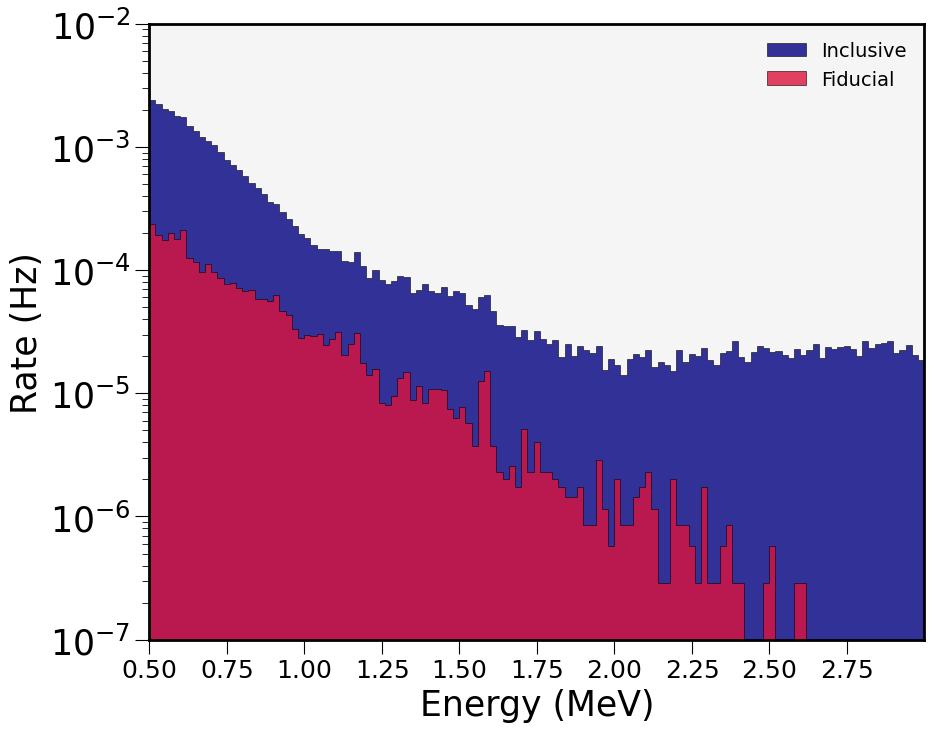

In [39]:
# Global
n_bins = 125
DEP_VALUE = 1.593       # MeV

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['E_final']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 3))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    duration = ANA_INFO['data']['duration']

    # Variable
    E_evt = dataframe['E_final']

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / duration    # in [Hz]
    print(f"{label.upper()}: counts = {counts.sum()}, corr. time = {duration:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
# plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=18)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $Z$ Distribution

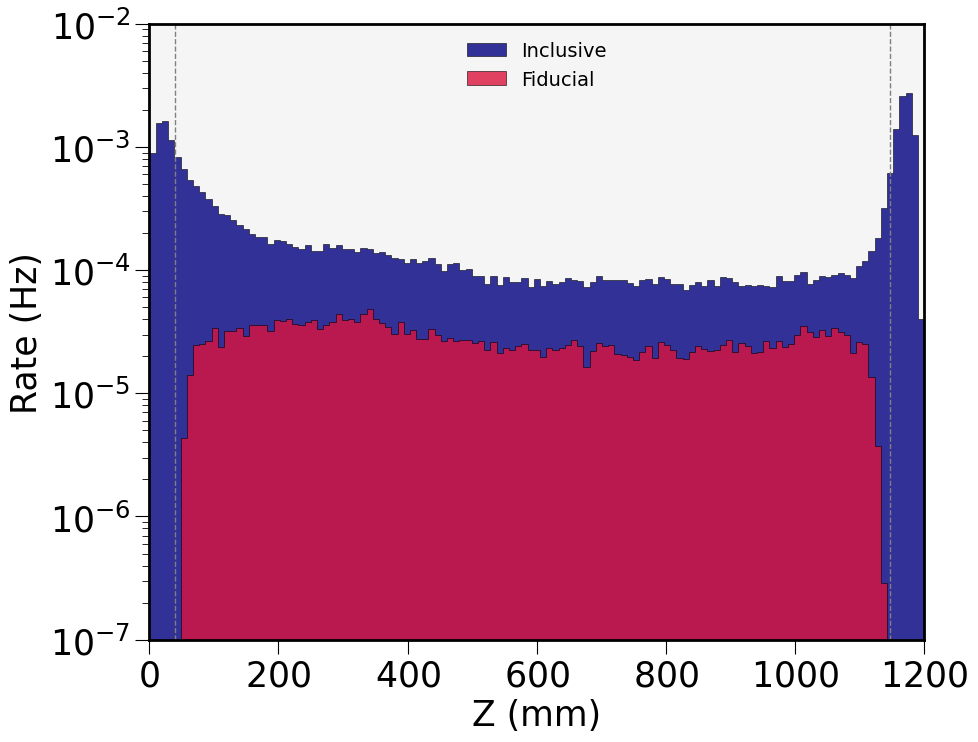

In [42]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['Z_bary']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 1200))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    duration = ANA_INFO['data']['duration']

    # Variable
    Z_evt = dataframe['Z_bary']

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=Z_LOW, c='gray', ls='--', lw=1.0)
plt.axvline(x=Z_UP, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

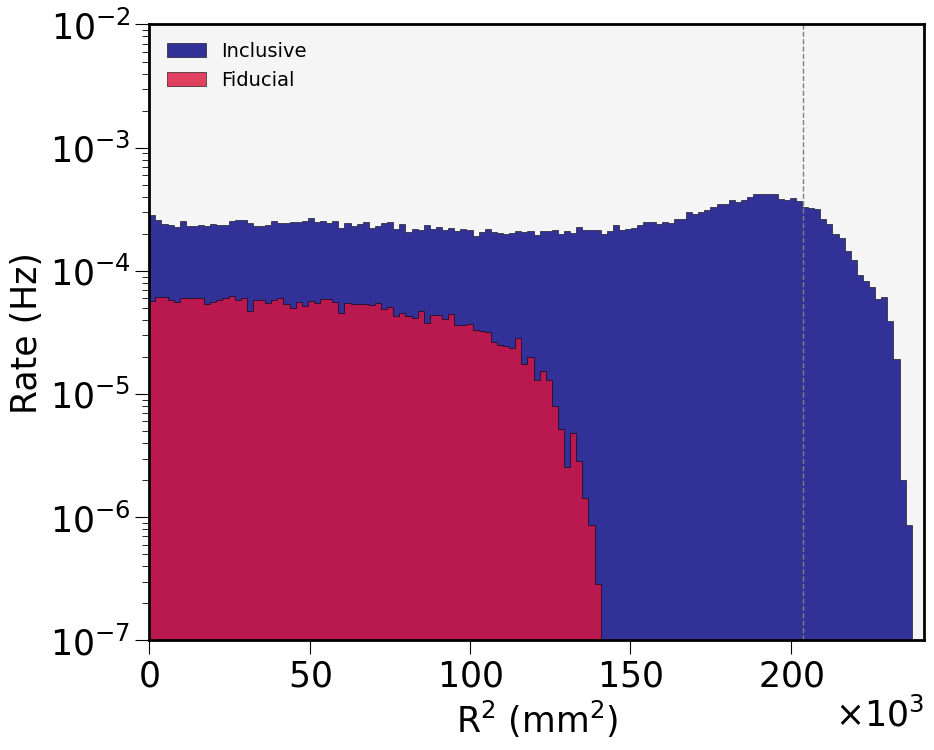

In [ ]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['X_bary']**2 + ANA_INFO['data']['df_inclusive']['Y_bary']**2
_, plot_edges = np.histogram(plot_var, bins=n_bins)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    duration = ANA_INFO['data']['duration']

    # Variable
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=R_UP**2, c='gray', ls='--', lw=1.0)
plt.axvline(x=crudo.pt.N100_rad**2, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, crudo.pt.N100_rad**2)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $XY$ Map

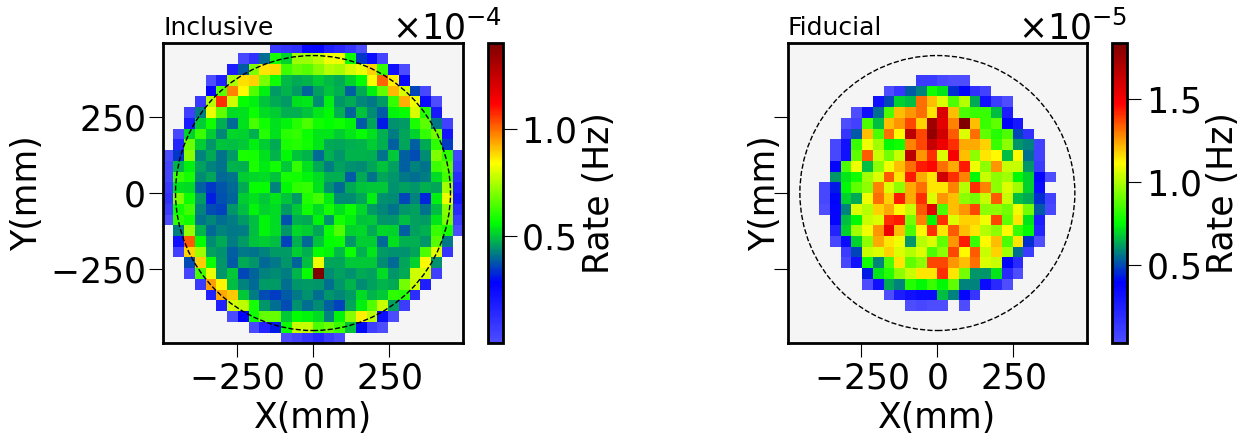

In [60]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    duration = ANA_INFO['data']['duration']

    # Variables
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']

    # 2D histogram: normalized by corrected DAQ data taking time
    XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, xy_bins=n_bins, pos=True)
    XY_rate            = XY_hit_map / duration      
    XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)
    # XY_rate            = np.clip(XY_rate, 0, 4e-5)

    # ----- Plotting ----- #
    im = axes[i].pcolormesh(ex, ey, XY_rate.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Rate (Hz)', shrink=1.0)
    cbar.formatter.set_powerlimits((-3, 3))
    axes[i].set_xlabel('X(mm)')
    axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_ylabel('Y(mm)')
    axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].add_patch(crudo.pt.plot_circle(R_UP, linestyle='--'))   # R-lim
    axes[i].set_title(f'{label}', fontsize=18, loc='left')
    axes[i].set_facecolor("whitesmoke")


plt.tight_layout()
plt.show()